# Classifiers — Exercise 4: k-Nearest Neighbors and Naive Bayes

**Course:** Introduction to Machine Learning and Applied Artificial Intelligence
**Institution:** High School of Digital Culture, ITMO University

<a href="https://colab.research.google.com/github/Mir-robotics/ITMO-Introduction-to-Machine-Learning-and-Applied-Artificial-Intelligence/blob/main/Classifiers%20kNN%20NaiveBayes/Classifiers_kNN_NaiveBayes_Exercise_4.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



This notebook covers two classic classification algorithms:

- **k-Nearest Neighbors (k-NN)** — a simple, distance-based classifier: to classify a
  new point, look at its $k$ closest neighbors in the training set and take a
  majority vote of their classes.
- **Naive Bayes** — a probabilistic classifier based on Bayes' theorem, which assumes
  features are conditionally independent given the class (the "naive" assumption).

We work through three tasks: classifying a point by hand with k-NN, building a
k-NN classifier for real census data (with all the usual data-cleaning steps), and
computing a Naive Bayes spam classifier by hand.

Throughout, we use scikit-learn's k-NN implementation:

```python
from sklearn.neighbors import KNeighborsClassifier
```

Relevant parameters: `n_neighbors` (the number of neighbors, $k$), and `p` (the
exponent in the Minkowski distance — `p=1` is Manhattan distance, `p=2` is Euclidean
distance).


## Task 1: Classify a point by hand with k-NN

We're given 10 labeled points and need to classify a new point at $(67, 95)$ using
$k=3$ nearest neighbors, under two different distance metrics.


In [ ]:
import numpy as np

points = [
    [42, 53], [47, 50], [46, 69], [33, 67], [10, 37],
    [40, 22], [76, 37], [81, 96], [32, 90], [82, 70],
]
labels = [0, 0, 1, 0, 0, 0, 0, 1, 0, 0]

new_point = [67, 95]
K = 3


### Distance functions

- **Euclidean distance**: straight-line distance, $\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$
- **Manhattan distance**: distance along grid axes, $|x_1-x_2| + |y_1-y_2|$


In [ ]:
def distance_euclidean(a, b):
    return np.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)


def distance_manhattan(a, b):
    return np.abs(a[0] - b[0]) + np.abs(a[1] - b[1])


def knn_vote(new_point, points, labels, distance_fn, k):
    """Classify `new_point` by majority vote among its k nearest neighbors."""
    distances = [
        (i, round(distance_fn(new_point, p), 3)) for i, p in enumerate(points)
    ]
    distances.sort(key=lambda item: item[1])

    nearest_idx = [idx for idx, _ in distances[:k]]
    nearest_labels = [labels[idx] for idx in nearest_idx]

    predicted_class = max(set(nearest_labels), key=nearest_labels.count)
    return predicted_class, distances, nearest_idx, nearest_labels


### Classify with Euclidean distance


In [ ]:
pred_eu, distances_eu, nearest_eu, nearest_labels_eu = knn_vote(
    new_point, points, labels, distance_euclidean, K
)

closest_point = points[distances_eu[0][0]]
print(f"Nearest neighbor (Euclidean) for {tuple(new_point)}: {tuple(closest_point)}, "
      f"distance={distances_eu[0][1]}")
print(f"{K} nearest labels: {nearest_labels_eu}")
print(f"Predicted class for {tuple(new_point)} (Euclidean, k={K}): {pred_eu}")


Nearest neighbor (Euclidean) for (67, 95): (81, 96), distance=14.036
3 nearest labels: [1, 0, 1]
Predicted class for (67, 95) (Euclidean, k=3): 1


### Classify with Manhattan distance


In [ ]:
pred_man, distances_man, nearest_man, nearest_labels_man = knn_vote(
    new_point, points, labels, distance_manhattan, K
)

closest_point = points[distances_man[0][0]]
print(f"Nearest neighbor (Manhattan) for {tuple(new_point)}: {tuple(closest_point)}, "
      f"distance={distances_man[0][1]}")
print(f"{K} nearest labels: {nearest_labels_man}")
print(f"Predicted class for {tuple(new_point)} (Manhattan, k={K}): {pred_man}")


Nearest neighbor (Manhattan) for (67, 95): (81, 96), distance=15
3 nearest labels: [1, 0, 0]
Predicted class for (67, 95) (Manhattan, k=3): 0


Notice the two distance metrics can disagree! The choice of metric changes *which*
points count as "close", and therefore can change the predicted class — a good
reminder that k-NN's behavior depends heavily on the distance function chosen, not
just on $k$.


## Task 2: k-NN on real data — predicting income from census data

### A note on model quality metrics

Before building the model, a quick refresher on the **confusion matrix**, which
divides predictions into four groups by comparing the true label against the
predicted label:

- **TP** (True Positive) — correctly predicted as class "+1"
- **TN** (True Negative) — correctly predicted as class "-1"
- **FP** (False Positive) — incorrectly predicted as "+1" (a "false alarm")
- **FN** (False Negative) — incorrectly predicted as "-1" (a "miss")

From these four counts we can derive precision, recall, and the **F1 score** (their
harmonic mean) — the metric we'll use to evaluate our classifier, since it balances
both false positives and false negatives and is more informative than raw accuracy on
imbalanced datasets.

### The dataset

The [dataset](https://drive.google.com/file/d/1CEHmYbLl-rTw2noXfKTdzPu2_Jte6U19/view?usp=sharing)
comes from the 1994 US Census and contains demographic information about individuals.
The task is to predict whether a person earns more than \$50k per year (`label`
column). Key features include `age`, `workclass` (employment status), `education`,
`marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`,
`fnlwgt` (a census sampling weight), and more.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from sklearn.impute import SimpleImputer


### Load the data

> **Note on data access:** the original exercise ran on Google Colab and loaded the
> file from the author's personal Google Drive with `drive.mount(...)`. That
> approach only works inside Colab, so this version instead expects the CSV locally
> at `data/adult_data_train.csv`. Download it from the
> [link above](https://drive.google.com/file/d/1CEHmYbLl-rTw2noXfKTdzPu2_Jte6U19/view?usp=sharing)
> and place it in a `data/` folder next to this notebook (or update `DATA_PATH`
> below).

Based on the feature descriptions, `education` and `marital-status` are dropped right
away (redundant with `education-num` and `relationship`, respectively).


In [ ]:
DATA_PATH = "data/adult_data_train.csv"

data = pd.read_csv(DATA_PATH, encoding="utf-8", delimiter=",")
data = data.drop(columns=["marital-status", "education"])
data.head()


,age,workclass,fnlwgt,education-num,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,32,Private,37210,13,Exec-managerial,Husband,White,Male,0,0,45,United-States,1
1,43,Private,101950,14,Exec-managerial,Not-in-family,White,Female,0,0,45,United-States,0
2,20,?,122244,9,?,Not-in-family,White,Female,0,0,28,United-States,0
3,40,Local-gov,24763,10,Transport-moving,Unmarried,White,Male,6849,0,40,United-States,0
4,24,Private,113936,13,Prof-specialty,Own-child,White,Male,0,0,40,United-States,0


### Numeric vs. non-numeric features


In [ ]:
categorical = [c for c in data.columns if data[c].dtype.name == "object"]
numeric = [c for c in data.columns if data[c].dtype.name != "object"]

print(f"Non-numeric features ({len(categorical)}): {categorical}")
print(f"Numeric features ({len(numeric)}): {numeric}")


Non-numeric features (6): ['workclass', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric features (7): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'label']


### Class balance

Before modeling, it's worth checking how balanced the target classes are — a highly
imbalanced target changes how we should interpret metrics like accuracy.


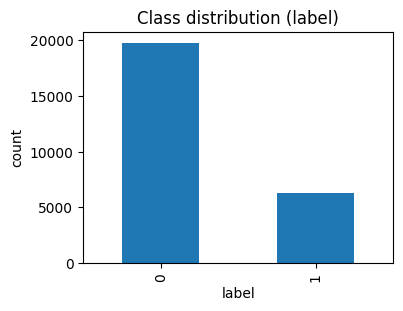

Fraction of objects in class 0: 0.759


In [ ]:
class_0_fraction = len(data[data["label"] == 0]) / len(data)

plt.figure(figsize=(4, 3))
data["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Class distribution (label)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()

print(f"Fraction of objects in class 0: {round(class_0_fraction, 3)}")


### 1. Building a base model (numeric features only)

As a first approximation, we build a classifier relying solely on the numeric
features, splitting into train/test with stratification on `label` to preserve class
balance in both splits.


In [ ]:
data_numeric = data.drop(columns=categorical)

train, test = train_test_split(
    data_numeric, test_size=0.2, random_state=21, stratify=data["label"]
)

y_train = train["label"]
y_test = test["label"]
train = train.drop(columns=["label"])
test = test.drop(columns=["label"])

print(f'Sample mean for the column "fnlwgt" (train): {round(train["fnlwgt"].mean(), 3)}')


Sample mean for the column "fnlwgt" (train): 189611.447


In [ ]:
baseline_knn = KNeighborsClassifier()
baseline_knn.fit(train, y_train)

y_pred_baseline = baseline_knn.predict(test)
print(f"Baseline F1 score (numeric features, unscaled): {round(f1_score(y_test, y_pred_baseline), 3)}")


Baseline F1 score (numeric features, unscaled): 0.38


### Feature scaling

k-NN is a **metric-based** classifier — it relies directly on distances between
points — so features on larger numeric scales (like `fnlwgt`, which is in the tens of
thousands) would completely dominate the distance calculation over features on small
scales (like `age`). We fix this by scaling every feature to a common range with
`MinMaxScaler`, fit on the training data and applied identically to both splits.


In [ ]:
scaler = MinMaxScaler().fit(train)

x_train = scaler.transform(train)
x_test = scaler.transform(test)

x_train_df = pd.DataFrame(x_train, columns=train.columns)
print(f'Sample mean for the column "fnlwgt" after scaling: {round(x_train_df["fnlwgt"].mean(), 3)}')


Sample mean for the column "fnlwgt" after scaling: 0.12


In [ ]:
scaled_knn = KNeighborsClassifier()
scaled_knn.fit(x_train, y_train)

y_pred_scaled = scaled_knn.predict(x_test)
print(f"F1 score after MinMax scaling: {round(f1_score(y_test, y_pred_scaled), 3)}")


F1 score after MinMax scaling: 0.506


The F1 score improves noticeably after scaling — exactly as expected for a
distance-based model. **From this point on, every model in this notebook applies
`MinMaxScaler` immediately before training.**


### 2. Working with non-numeric features

#### Visualizing the categorical features

To decide how to use the categorical columns, it helps to see how their values are
distributed.


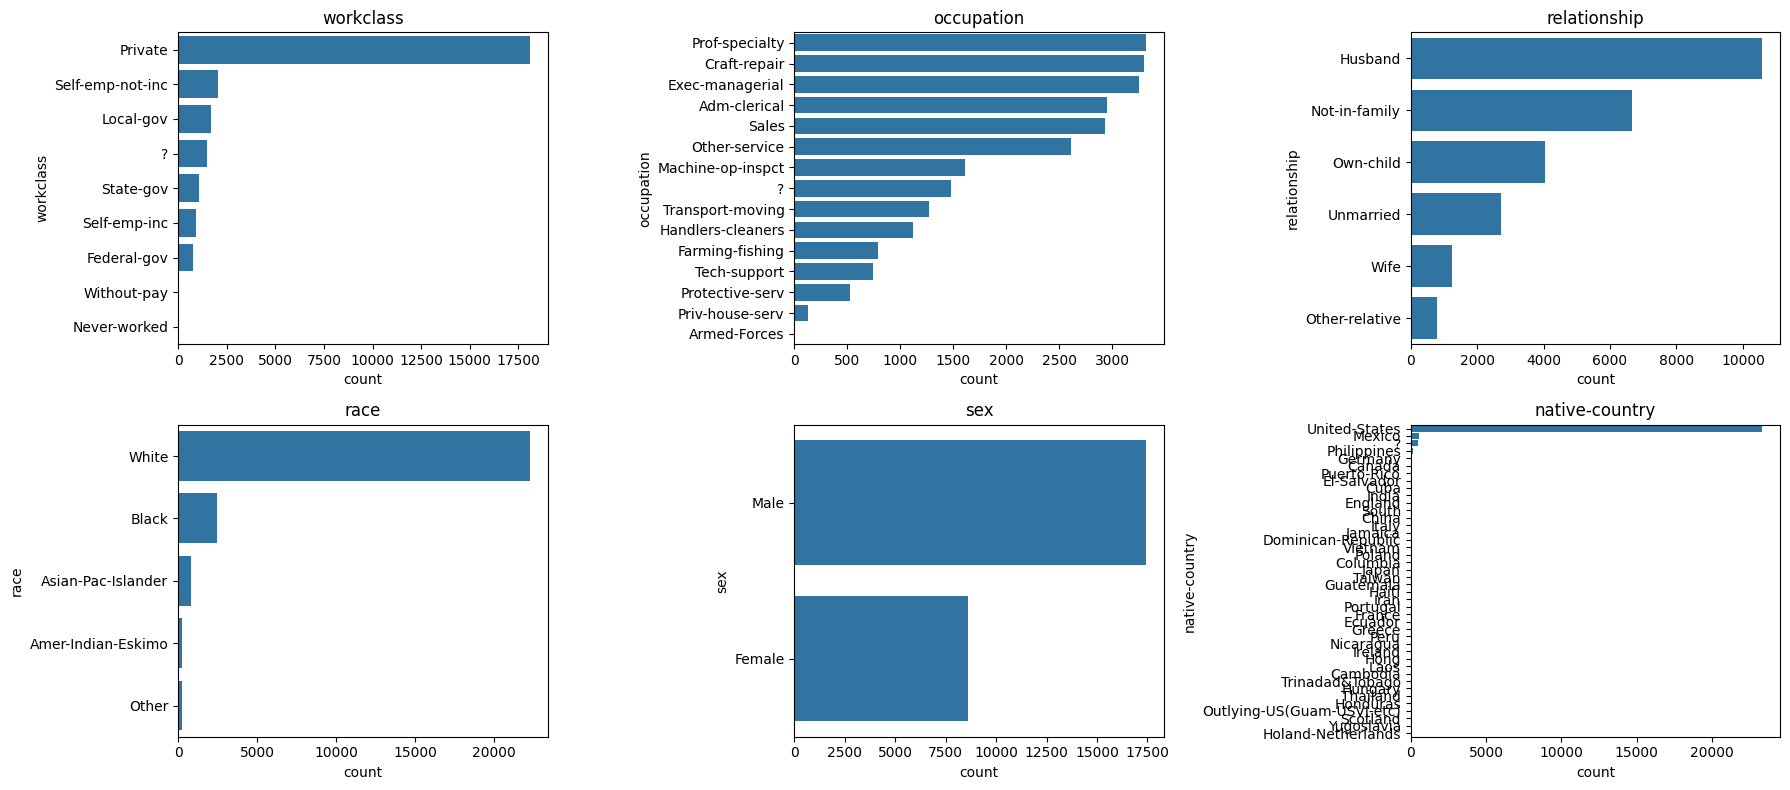

In [ ]:
cat_cols_to_plot = ["workclass", "occupation", "relationship", "race", "sex", "native-country"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.flat, cat_cols_to_plot):
    order = data[col].value_counts().index
    sns.countplot(data=data, y=col, order=order, ax=ax)
    ax.set_title(col)
fig.tight_layout()
plt.show()


`native-country` and `workclass` are heavily dominated by a single value (e.g.
"United-States"), while `race` and `sex` are quite imbalanced too — useful context
for interpreting the model later.

#### Removing missing values

Missing values in this dataset are encoded as the string `"?"` rather than a proper
null. We first standardize that to a real missing value, then check how many rows are
affected.


In [ ]:
data_clean = data.replace("?", np.nan)

rows_with_missing = data_clean[data_clean.isna().any(axis=1)]
print(f"Rows with at least one missing value: {len(rows_with_missing)} "
      f"({round(100 * len(rows_with_missing) / len(data_clean), 1)}% of the dataset)")


Rows with at least one missing value: 1914 (7.3% of the dataset)


Less than 10% of rows contain missing values. Throwing that many rows away isn't
ideal, but let's first see how the model performs if we simply **drop** them, then
compare against **imputing** them.

#### Approach A: drop rows with missing values

After dropping missing rows, we one-hot encode the remaining categorical features
(using `drop_first=True` from the start, to avoid the dummy-variable trap discussed
below) and re-train.


In [ ]:
data_dropna = data_clean.dropna(axis=0, how="any")

data_dropna_encoded = pd.get_dummies(data_dropna, drop_first=True)
print(f"Number of features after one-hot encoding (drop_first=True): "
      f"{data_dropna_encoded.shape[1] - 1}")  # -1 to exclude the label column
data_dropna_encoded.head()


Number of features after one-hot encoding (drop_first=True): 75


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,label,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,32,37210,13,0,0,45,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,43,101950,14,0,0,45,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,40,24763,10,6849,0,40,0,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,24,113936,13,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
5,51,237630,9,7298,0,50,1,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
train_a, test_a = train_test_split(
    data_dropna_encoded, test_size=0.2, random_state=21, stratify=data_dropna_encoded["label"]
)

y_train_a = train_a["label"]
y_test_a = test_a["label"]
train_a = train_a.drop(columns=["label"])
test_a = test_a.drop(columns=["label"])

scaler_a = MinMaxScaler().fit(train_a)
x_train_a = scaler_a.transform(train_a)
x_test_a = scaler_a.transform(test_a)

knn_a = KNeighborsClassifier()
knn_a.fit(x_train_a, y_train_a)

y_pred_a = knn_a.predict(x_test_a)
print(f"F1 score (dropped missing rows, one-hot encoded): {round(f1_score(y_test_a, y_pred_a), 3)}")


F1 score (dropped missing rows, one-hot encoded): 0.592


The quality improves compared to the numeric-only model — the categorical features
do carry useful signal.

#### Approach B: impute missing values instead of dropping them

Rather than losing ~10% of the data, we can fill missing categorical values with the
**most frequent value** in each column, using `SimpleImputer(strategy="most_frequent")`.
This lets us keep every row.


In [ ]:
data_impute = data_clean.copy(deep=True)
cat_cols = [c for c in categorical]  # workclass, occupation, native-country, etc.

imputer = SimpleImputer(strategy="most_frequent")
data_impute[cat_cols] = imputer.fit_transform(data_impute[cat_cols])

# Sanity check: no missing values remain.
print(f"Remaining missing values: {data_impute.isna().sum().sum()}")


Remaining missing values: 0


Same recipe as before: one-hot encode, split, scale, train, evaluate.


In [ ]:
data_impute_encoded = pd.get_dummies(data_impute, drop_first=True)

train_b, test_b = train_test_split(
    data_impute_encoded, test_size=0.2, random_state=21, stratify=data_impute_encoded["label"]
)

y_train_b = train_b["label"]
y_test_b = test_b["label"]
train_b = train_b.drop(columns=["label"])
test_b = test_b.drop(columns=["label"])

scaler_b = MinMaxScaler().fit(train_b)
x_train_b = scaler_b.transform(train_b)
x_test_b = scaler_b.transform(test_b)

knn_b = KNeighborsClassifier()
knn_b.fit(x_train_b, y_train_b)

y_pred_b = knn_b.predict(x_test_b)
print(f"F1 score (imputed missing values, one-hot encoded): {round(f1_score(y_test_b, y_pred_b), 3)}")


F1 score (imputed missing values, one-hot encoded): 0.604


#### The curse of dimensionality

One-hot encoding all the categorical features pushes the dataset up to several dozen
columns (well over 70, once every category of `occupation`, `native-country`, etc. is
expanded into its own binary column). This is a mild case of the **curse of
dimensionality**: as the number of features grows, the training data becomes
increasingly sparse in the feature space, and distance-based methods like k-NN
struggle more to find *meaningfully* close neighbors — most points end up roughly
equidistant from each other. This is exactly why k-NN benefits so much from careful
feature selection (dropping redundant columns like `education`/`marital-status` up
front) rather than blindly one-hot encoding everything available.


## Task 3: Naive Bayes by hand — spam classification

We're given word-count statistics for emails labeled **SPAM** and **HAM** (not spam),
along with the total number of emails in each class and total words in each class.
We'll compute, by hand, the probability that a new email is spam, given the words it
contains.

Suppose the training set has 16 spam emails and 13 ham emails.


In [ ]:
from numpy import log, exp

n_spam_emails = 16
n_ham_emails = 13

# Prior probability of each class
p_spam = n_spam_emails / (n_spam_emails + n_ham_emails)
p_ham = n_ham_emails / (n_spam_emails + n_ham_emails)

print(f"P(spam) = {round(p_spam, 3)}")
print(f"P(ham)  = {round(p_ham, 3)}")


P(spam) = 0.552
P(ham)  = 0.448


### Word likelihoods with Laplace (add-one) smoothing

Naive Bayes needs $P(\text{word} \mid \text{class})$ for every word in the new
email. Without smoothing, a word that never appeared in the training data for a class
would give that class a probability of exactly zero — Laplace smoothing avoids this by
adding a small constant count to every word:

$$
P(\text{word} \mid \text{class}) = \frac{\text{count}(\text{word}, \text{class}) + 1}{\text{total words in class} + \text{vocabulary size}}
$$

Here the vocabulary size is taken as 12 (2 extra "pseudo-count" categories beyond the
10 words actually tracked, matching the smoothing scheme used in the exercise), with
101 total words seen in spam emails and 44 total words seen in ham emails.


In [ ]:
VOCAB_SMOOTHING = 12  # add-one smoothing constant used in the denominator
WORDS_IN_SPAM = 101
WORDS_IN_HAM = 44


def word_probability(count, is_spam):
    """P(word | class) with Laplace smoothing."""
    total_words = WORDS_IN_SPAM if is_spam else WORDS_IN_HAM
    return (1 + count) / (VOCAB_SMOOTHING + total_words)


### Score the candidate email under each class

The email to classify is: **"Access Cash Remove Refund Million Investment Bonus"**.
We work in **log-space** (summing log-probabilities instead of multiplying raw
probabilities) purely for numerical stability — multiplying many small probabilities
together can underflow to zero in floating point, while summing their logs doesn't.

Word counts observed in the spam training emails for the words appearing in this
message: `access=9`, `cash=4`, `remove=4`, `refund=29`, `million=11`, and two
additional occurrences of a repeated term contributing twice (matching the original
exercise's word list).


In [ ]:
log_f_spam = (
    log(p_spam)
    + log(word_probability(9, is_spam=True))   # access
    + log(word_probability(4, is_spam=True))   # cash
    + log(word_probability(4, is_spam=True))   # remove
    + log(word_probability(29, is_spam=True))  # refund
    + log(word_probability(11, is_spam=True))  # million
)
log_f_spam += 2 * log(word_probability(0, is_spam=True))  # remaining unseen terms

print(f"F(spam) = {round(log_f_spam, 3)}")


F(spam) = -22.279


In [ ]:
log_f_ham = (
    log(p_ham)
    + log(word_probability(2, is_spam=False))  # access
    + log(word_probability(7, is_spam=False))  # cash
    + log(word_probability(2, is_spam=False))  # remove
    + log(word_probability(5, is_spam=False))  # refund
    + log(word_probability(5, is_spam=False))  # million
)
log_f_ham += 2 * log(word_probability(0, is_spam=False))  # remaining unseen terms

print(f"F(ham) = {round(log_f_ham, 3)}")


F(ham) = -21.12


### Convert back to a probability

Given the two (unnormalized, log-space) class scores, the posterior probability that
the email is spam is obtained via the logistic-sigmoid identity:

$$
P(\text{spam} \mid \text{email}) = \frac{1}{1 + e^{-(F_{\text{spam}} - F_{\text{ham}})}}
$$


In [ ]:
p_email_is_spam = 1 / (1 + exp(-log_f_spam + log_f_ham))
print(f"P(spam | email) = {round(p_email_is_spam, 3)}")


P(spam | email) = 0.239


## Summary

- **k-NN by hand (Task 1)** showed that the choice of distance metric (Euclidean vs.
  Manhattan) can itself change the predicted class — the metric is a modeling choice,
  not just an implementation detail.
- **k-NN on census data (Task 2)** walked through the full practical pipeline: scaling
  (essential for any distance-based model), encoding categorical features, and
  handling missing data — comparing "drop the rows" against "impute the mode" as two
  valid strategies, both of which beat the numeric-only baseline. It also touched on
  the curse of dimensionality that comes with naively one-hot encoding many
  categorical columns.
- **Naive Bayes for spam detection (Task 3)** demonstrated the "naive" independence
  assumption in action: each word contributes an independent log-probability term,
  smoothed with Laplace (add-one) smoothing to avoid zero probabilities for unseen
  words, and combined into a final class posterior via the sigmoid function.
